Dataset Overview
Shape     : (5659, 10)
Columns   : ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

First 5 rows:

                                 Name  Year  Duration  \
0  #Gadhvi (He thought he was Gandhi)  2019       109   
1                             #Yaaram  2019       110   
2                ...Aur Pyaar Ho Gaya  1997       147   
3                           ...Yahaan  2005       142   
4                  ?: A Question Mark  2012        82   

                       Genre  Rating  Votes        Director          Actor 1  \
0                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
1            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
2     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
3        Drama, Romance, War     7.4   1086  Shoojit Sircar  Jimmy Sheirgill   
4  Horror, Mystery, Thriller     5.6    326   Allyson Patel        Yash Dave   

      

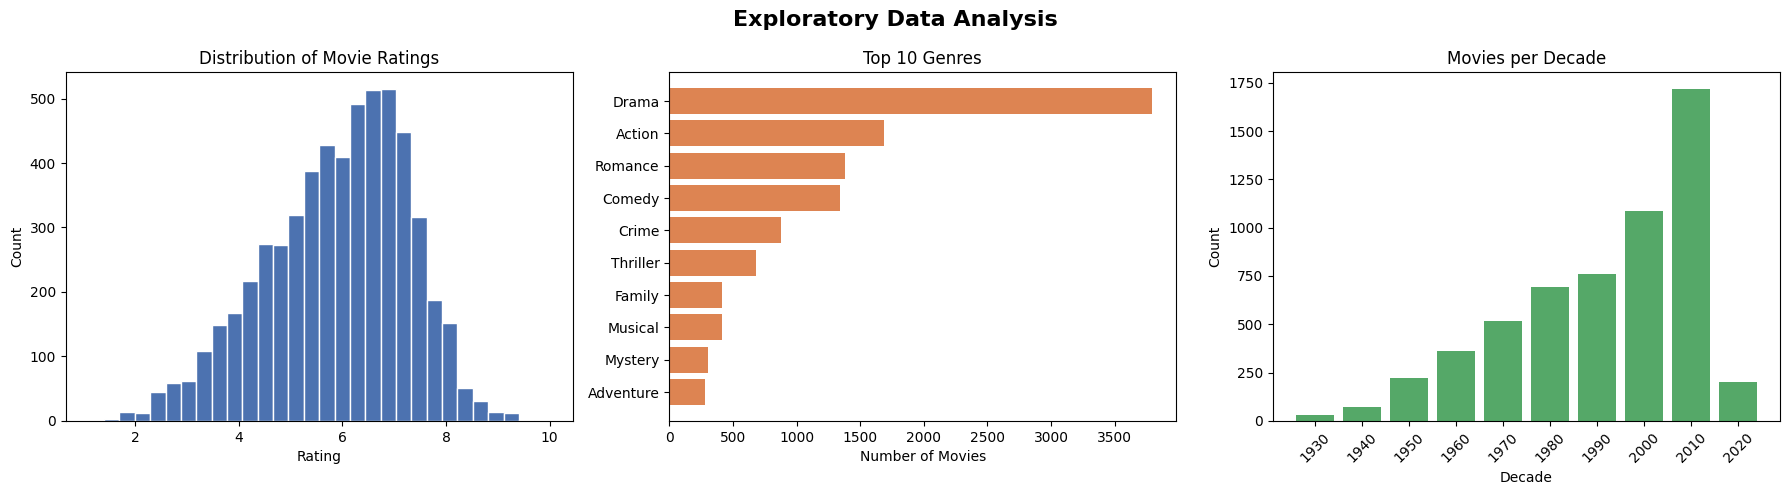


EDA plots saved as 'eda_plots.png'

TF-IDF Matrix Shape : (5659, 5000)

Training samples : 4527
Testing  samples : 1132

Model Training Completed ✓

       Model Performance Metrics
  RMSE     : 1.2081
  R² Score : 0.2119


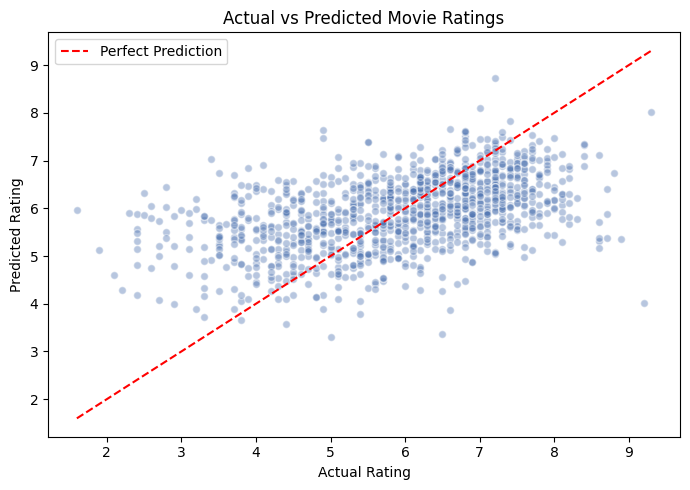

Plot saved as 'actual_vs_predicted.png'

Computing cosine similarity matrix ...
Done ✓

   Movie Recommendation System



Enter a movie you like:  PAA



✔  Found : 'Paa'
   Genre  : Comedy, Drama
   Rating : 7.2

─────────────────────────────────────────────
  Top 5 Recommended Movies
─────────────────────────────────────────────
  1. Cheeni Kum                               Rating: 6.8  |  Genre: Comedy, Drama, Romance
  2. Sarkar Raj                               Rating: 6.7  |  Genre: Action, Crime, Drama
  3. Ki & Ka                                  Rating: 5.8  |  Genre: Comedy, Romance
  4. Bol Bachchan                             Rating: 5.5  |  Genre: Action, Comedy
  5. Mahabharat                               Rating: 5.3  |  Genre: Animation, Action, Adventure
─────────────────────────────────────────────



In [10]:

# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
 
# LOAD DATASET

df = pd.read_csv("movies_data.csv")
 
print("=" * 50)
print("Dataset Overview")
print("=" * 50)
print(f"Shape     : {df.shape}")
print(f"Columns   : {list(df.columns)}")
print(f"\nFirst 5 rows:\n")
print(df.head())
 
 
# DATA CLEANING
 
# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"\nDuplicates removed : {before - len(df)}")
 
# Strip whitespace from string columns
df["Name"]     = df["Name"].str.strip()
df["Genre"]    = df["Genre"].str.strip()
df["Director"] = df["Director"].str.strip()
df["Actor 1"]  = df["Actor 1"].str.strip()
df["Actor 2"]  = df["Actor 2"].str.strip()
df["Actor 3"]  = df["Actor 3"].str.strip()
 
# Convert numeric columns (coerce bad values to NaN)
df["Year"]     = pd.to_numeric(df["Year"],     errors="coerce")
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")
df["Rating"]   = pd.to_numeric(df["Rating"],   errors="coerce")
df["Votes"]    = pd.to_numeric(df["Votes"],     errors="coerce")
 
# Drop rows with missing values in critical columns
df = df.dropna(subset=["Rating", "Genre", "Director", "Actor 1"])
df = df.reset_index(drop=True)
 
print(f"Cleaned Dataset Shape : {df.shape}")
print(f"\nRating Statistics:\n{df['Rating'].describe()}")
 
 
# EXPLORATORY DATA ANALYSIS
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")
 
# Rating Distribution
axes[0].hist(df["Rating"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Movie Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
 
# Top 10 Genres
genre_counts = (df["Genre"].str.split(", ").explode().value_counts().head(10))
axes[1].barh(genre_counts.index[::-1], genre_counts.values[::-1], color="#DD8452")
axes[1].set_title("Top 10 Genres")
axes[1].set_xlabel("Number of Movies")
 
# Movies per Decade
df["Decade"] = (df["Year"] // 10 * 10).astype(int)
decade_counts = df["Decade"].value_counts().sort_index()
axes[2].bar(decade_counts.index.astype(str), decade_counts.values, color="#55A868")
axes[2].set_title("Movies per Decade")
axes[2].set_xlabel("Decade")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nEDA plots saved as 'eda_plots.png'")
 
 
# FEATURE ENGINEERING
 
# Combine text features into one column for TF-IDF
df["combined_features"] = (df["Genre"]    + " " + df["Director"] + " " + df["Actor 1"]  + " " + df["Actor 2"]  + " " + df["Actor 3"])
 
# Convert text into numerical TF-IDF vectors
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(df["combined_features"])
 
print(f"\nTF-IDF Matrix Shape : {tfidf_matrix.shape}")
 

# TRAIN-TEST SPLIT

X = tfidf_matrix
y = df["Rating"]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


# TRAIN MACHINE LEARNING MODEL

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
 
print("\nModel Training Completed ✓")
 
 
# MODEL EVALUATION

y_pred = model.predict(X_test)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
 
print("\n" + "=" * 40)
print("       Model Performance Metrics")
print("=" * 40)
print(f"  RMSE     : {rmse:.4f}")
print(f"  R² Score : {r2:.4f}")
print("=" * 40)
 
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color="#4C72B0", edgecolors="white", s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as 'actual_vs_predicted.png'")
 

# MOVIE RECOMMENDATION SYSTEM
 
# Pre-compute cosine similarity matrix
print("\nComputing cosine similarity matrix ...")
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Done ✓")
 
 
def recommend_movies(movie_title: str, num_recommendations: int = 5) -> None:
    import re
 
    query = movie_title.strip()
 
    # 1. Exact match
    matches = df[df["Name"].str.lower() == query.lower()]
 
    # 2. Word-boundary match  (whole-word, e.g. "PK" won't hit "Aapko")
    if matches.empty:
        pattern = r"(?<!\w)" + re.escape(query) + r"(?!\w)"
        matches = df[df["Name"].str.contains(pattern, case=False, na=False, regex=True)]
 
    # 3. Substring fallback
    if matches.empty:
        matches = df[df["Name"].str.contains(re.escape(query), case=False, na=False, regex=True)]
 
    # --- Disambiguation: if multiple hits, let user pick ---
    if len(matches) > 1:
        print(f"\n  Multiple movies found for '{query}':")
        for i, (row_idx, row) in enumerate(matches.head(8).iterrows(), start=1):
            print(f"    {i}. {row['Name']:<45} Year: {int(row['Year'])}  Rating: {row['Rating']}")
        try:
            choice = int(input(f"\n  Enter number (1-{min(len(matches), 8)}): ").strip())
            choice = max(1, min(choice, min(len(matches), 8)))
        except ValueError:
            choice = 1
        matches = matches.iloc[[choice - 1]]
 
    if not matches.empty:
        idx = matches.index[0]
        found_title = df.loc[idx, "Name"]
 
        print(f"\n✔  Found : '{found_title}'")
        print(f"   Genre  : {df.loc[idx, 'Genre']}")
        print(f"   Rating : {df.loc[idx, 'Rating']}")
        print(f"\n{'─' * 45}")
        print(f"  Top {num_recommendations} Recommended Movies")
        print(f"{'─' * 45}")
 
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1 : num_recommendations + 1]
 
        # Sort final candidates by rating (highest first)
        sim_scores = sorted(sim_scores, key=lambda x: df.loc[x[0], "Rating"], reverse=True)
 
        for rank, (i, score) in enumerate(sim_scores, start=1):
            print(
                f"  {rank}. {df.loc[i, 'Name']:<40} "
                f"Rating: {df.loc[i, 'Rating']}  |  "
                f"Genre: {df.loc[i, 'Genre']}"
            )
        print(f"{'─' * 45}\n")
 
    else:
        # --- Fallback: recommend by genre ---
        print(f"\n✘  '{movie_title}' not found in the dataset.")
        user_genre = input("   Enter your preferred genre (e.g. Drama, Action): ").strip()
 
        genre_movies = df[df["Genre"].str.contains(user_genre, case=False, na=False)]
 
        if not genre_movies.empty:
            top_movies = (
                genre_movies
                .sort_values("Rating", ascending=False)
                .head(num_recommendations)
            )
            print(f"\n  Top {num_recommendations} '{user_genre}' Movies by Rating")
            print(f"{'─' * 45}")
            for rank, (_, row) in enumerate(top_movies.iterrows(), start=1):
                print(
                    f"  {rank}. {row['Name']:<40} "
                    f"Rating: {row['Rating']}  |  "
                    f"Year: {int(row['Year'])}"
                )
            print(f"{'─' * 45}\n")
        else:
            print(f"\n  No movies found for genre '{user_genre}' either. "
                  "Please try a different genre.\n")
 
# INPUT BY USER

print("\n" + "=" * 50)
print("   Movie Recommendation System")
print("=" * 50)
 
movie = input("\nEnter a movie you like: ").strip()
recommend_movies(movie)